In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

In [5]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

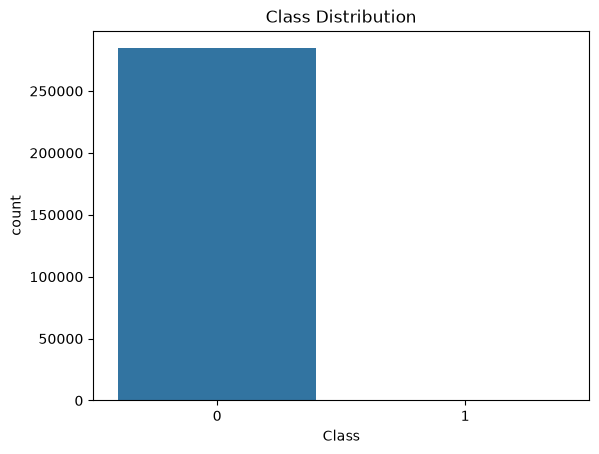

In [11]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [14]:
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

In [15]:
y.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

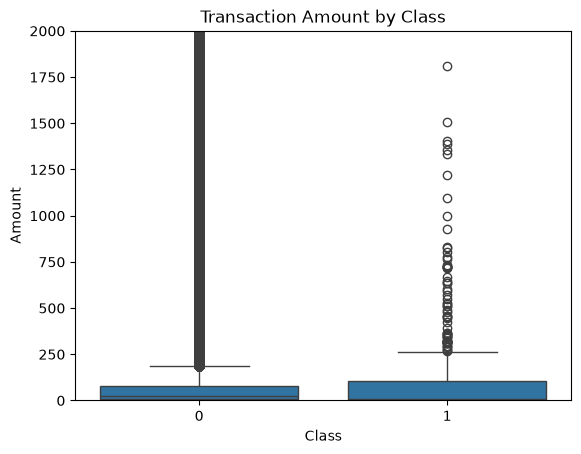

In [16]:
plt.figure()

sns.boxplot(x='Class', y='Amount', data=df)

plt.title("Transaction Amount by Class")
plt.ylim(0, 2000)  
plt.show()

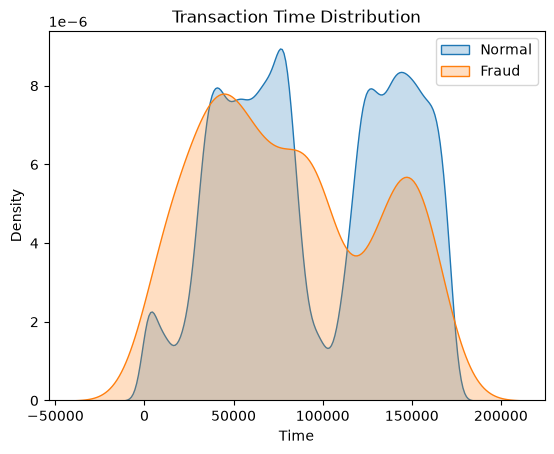

In [17]:
plt.figure()

sns.kdeplot(df[df['Class'] == 0]['Time'], label='Normal', fill=True)
sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraud', fill=True)

plt.title("Transaction Time Distribution")
plt.legend()
plt.show()

In [18]:
!pip install imbalanced-learn

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
class_weight='balanced'

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[55475  1389]
 [    8    90]]


In [26]:
import pickle

with open("../backend/models/fraud_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [27]:
with open("../backend/models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [30]:
model_path = os.path.join("..", "backend", "models", "fraud_model.pkl")
scaler_path = os.path.join("..", "backend", "models", "scaler.pkl")

with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

with open(scaler_path, "rb") as f:
    scaler = pickle.load(f)

In [31]:
sample = X_test.iloc[0].values.reshape(1, -1)

pred = loaded_model.predict(sample)
print(pred)

[0]


C:\Users\Dell i5 7th G\AI_ML_Internship_Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [32]:
sample = X_test.iloc[[0]] 
pred = loaded_model.predict(sample)

print(pred)

[0]


In [33]:
!pip install xgboost

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [35]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=42)
}

In [36]:
results = []

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

In [41]:
comparison_df = pd.DataFrame(results)
comparison_df.sort_values(by="F1 Score",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.999596,0.941176,0.816327,0.874317
3,KNN,0.999544,0.918605,0.806122,0.858696
4,XGBoost,0.999491,0.896552,0.795918,0.843243
1,Decision Tree,0.999140,0.752577,0.744898,0.748718
0,Logistic Regression,0.999140,0.826667,0.632653,0.716763


In [42]:
results = []

In [43]:
for name, model in models.items():

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("\n" + "="*60)
    print(f"Model: {name}")
    print("="*60)

    print(classification_report(y_test, y_pred, zero_division=0))

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })


Model: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


Model: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962


Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
we

In [44]:
from sklearn.metrics import classification_report


In [45]:
results = []

In [46]:
for name, model in models.items():

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("\n" + "="*60)
    print(f"Model: {name}")
    print("="*60)

    print(classification_report(y_test, y_pred, zero_division=0))

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })


Model: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


Model: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962


Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
we

In [47]:
reports = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    reports[name] = classification_report(y_test, y_pred, output_dict=True)

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

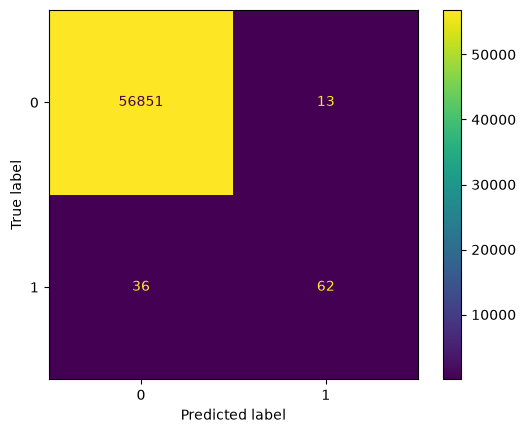

In [49]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.show

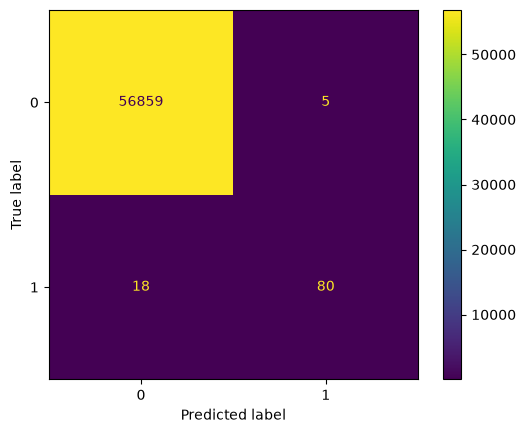

In [50]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

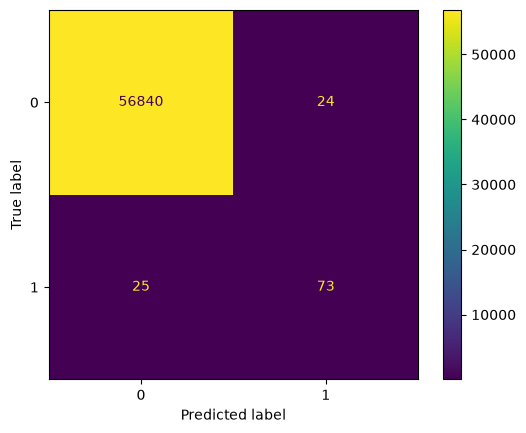

In [51]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.show()

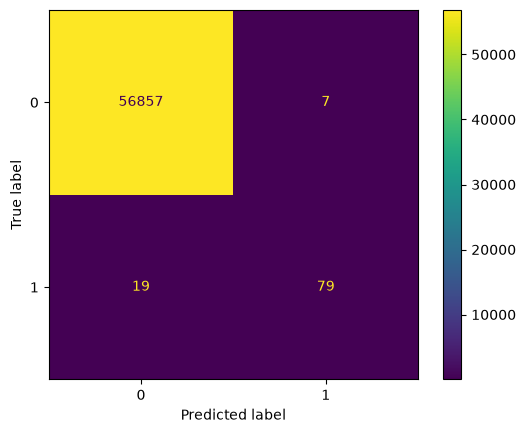

In [52]:
kn = KNeighborsClassifier()
kn.fit(X_train_scaled, y_train)
y_pred_kn = kn.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_kn)
plt.show()

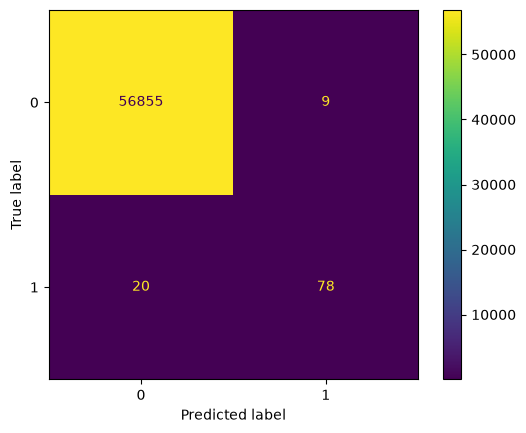

In [53]:
xg = XGBClassifier(random_state=42)
xg.fit(X_train_scaled, y_train)
y_pred_xg = xg.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xg)
plt.show()

In [54]:
i = 0  
sample = X_test.iloc[i]
actual = y_test.iloc[i]

In [55]:
sample.tolist()

[160760.0,
 -0.674466064578314,
 1.40810501967799,
 -1.11062205357093,
 -1.32836577843066,
 1.38899603254837,
 -1.30843906707795,
 1.88587890268717,
 -0.614232966299775,
 0.311652212453101,
 0.65075700363522,
 -0.857784661547805,
 -0.229961445775592,
 -0.19981700479103,
 0.266371326329879,
 -0.0465441684754424,
 -0.741398089749789,
 -0.605616644106022,
 -0.39256818789208,
 -0.162648311024695,
 0.394321820843914,
 0.0800842396026648,
 0.810033595602455,
 -0.224327230436412,
 0.707899237446867,
 -0.13583702273753,
 0.0451021964988772,
 0.533837219064273,
 0.291319252625364,
 23.0]

In [56]:
i = 60  
sample = X_test.iloc[i]
actual = y_test.iloc[i]

In [57]:
sample.tolist()

[105358.0,
 1.99012495563867,
 -0.196218859846072,
 -0.158397177403298,
 0.546180967575316,
 -0.668479509385521,
 -0.728145006485968,
 -0.59354946086915,
 -0.122373855105682,
 2.71014604458131,
 -0.585029771932224,
 0.163403067616218,
 -2.34025256486887,
 1.0500848663879,
 1.64777047376952,
 0.448493107931446,
 0.164732169546989,
 0.170524027212332,
 0.278438294247306,
 -0.417824165644306,
 -0.337139134069615,
 -0.270326327406331,
 -0.418599981093457,
 0.379359028702217,
 -0.151898196130626,
 -0.428486910140282,
 -0.957451509043521,
 0.0312698181333902,
 -0.0351372071337904,
 2.12]

In [58]:
fraud_samples = X_test[y_test == 1]

In [59]:
i = 0  
sample = fraud_samples.iloc[i]
actual = 1 


In [60]:
sample.tolist()

[57007.0,
 -1.27124419171437,
 2.46267526851135,
 -2.85139500331783,
 2.3244800653478,
 -1.37224488981369,
 -0.948195686538643,
 -3.06523436172054,
 1.16692694787211,
 -2.26877058844813,
 -4.88114292689057,
 2.25514748870463,
 -4.68638689759229,
 0.652374668512965,
 -6.17428834800643,
 0.594379608016446,
 -4.84969238709652,
 -6.53652073527011,
 -3.11909388163881,
 1.71549441975915,
 0.560478075726644,
 0.652941051330455,
 0.0819309763507574,
 -0.221347831198339,
 -0.523582159233306,
 0.224228161862968,
 0.756334522703558,
 0.632800477330469,
 0.250187092757197,
 0.01]

In [61]:
model.predict([sample])[0]

np.int64(1)

In [63]:
df_original = df.copy()

In [64]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
test_df = X_test.copy()
test_df["Class"] = y_test.values

In [66]:
fraud_rows = test_df[test_df["Class"] == 1]

In [67]:
fraud_rows.shape

(98, 31)

In [68]:
sample = fraud_rows.iloc[0]

actual = sample["Class"]
features = sample.drop("Class").values

In [69]:
model.predict(scaler.transform([features]))

C:\Users\Dell i5 7th G\AI_ML_Internship_Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1])

In [70]:
print("Actual:", actual)
print("Predicted:", prediction)

Actual: 1.0


NameError: name 'prediction' is not defined

In [71]:
prediction = model.predict(scaler.transform([features]))[0]

print("Actual:", actual)
print("Predicted:", prediction)

Actual: 1.0
Predicted: 1


C:\Users\Dell i5 7th G\AI_ML_Internship_Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [72]:
features.tolist()

[57007.0,
 -1.27124419171437,
 2.46267526851135,
 -2.85139500331783,
 2.3244800653478,
 -1.37224488981369,
 -0.948195686538643,
 -3.06523436172054,
 1.16692694787211,
 -2.26877058844813,
 -4.88114292689057,
 2.25514748870463,
 -4.68638689759229,
 0.652374668512965,
 -6.17428834800643,
 0.594379608016446,
 -4.84969238709652,
 -6.53652073527011,
 -3.11909388163881,
 1.71549441975915,
 0.560478075726644,
 0.652941051330455,
 0.0819309763507574,
 -0.221347831198339,
 -0.523582159233306,
 0.224228161862968,
 0.756334522703558,
 0.632800477330469,
 0.250187092757197,
 0.01]

In [73]:
print(type(model))
print(type(scaler))

<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.preprocessing._data.StandardScaler'>


In [74]:
print(pred)

[0]


In [75]:
input_array = np.array(features).reshape(1, -1)
scaled = scaler.transform(input_array)
pred = model.predict(scaled)

C:\Users\Dell i5 7th G\AI_ML_Internship_Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [76]:
feature_names = [
    "Time", "Amount",
    "V1","V2","V3","V4","V5","V6","V7","V8","V9","V10",
    "V11","V12","V13","V14","V15","V16","V17","V18","V19","V20",
    "V21","V22","V23","V24","V25","V26","V27","V28"
]

In [77]:
import pandas as pd
import numpy as np

def predict(features):
    df_input = pd.DataFrame([features], columns=feature_names)

    scaled = scaler.transform(df_input)
    pred = model.predict(scaled)

    return int(pred[0])

In [78]:
print(pred)

[1]


In [79]:
fraud_df = df[df["Class"] == 1]

In [80]:
len(fraud_df)

492

In [81]:
sample_row = fraud_df.iloc[0]

In [82]:
actual = sample_row["Class"]
features = sample_row.drop("Class")

In [83]:
features = features.values.reshape(1, -1)

In [84]:
scaled = scaler.transform(features)
pred = model.predict(scaled)

print("Actual:", actual)
print("Predicted:", pred[0])

Actual: 1.0
Predicted: 1


C:\Users\Dell i5 7th G\AI_ML_Internship_Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [85]:
features.values.flatten().tolist()

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [86]:
features.flatten().tolist()

[406.0,
 -2.3122265423263,
 1.95199201064158,
 -1.60985073229769,
 3.9979055875468,
 -0.522187864667764,
 -1.42654531920595,
 -2.53738730624579,
 1.39165724829804,
 -2.77008927719433,
 -2.77227214465915,
 3.20203320709635,
 -2.89990738849473,
 -0.595221881324605,
 -4.28925378244217,
 0.389724120274487,
 -1.14074717980657,
 -2.83005567450437,
 -0.0168224681808257,
 0.416955705037907,
 0.126910559061474,
 0.517232370861764,
 -0.0350493686052974,
 -0.465211076182388,
 0.320198198514526,
 0.0445191674731724,
 0.177839798284401,
 0.261145002567677,
 -0.143275874698919,
 0.0]

In [88]:
y_pred = model.predict(X_test_scaled)

In [89]:
comparison_df = pd.DataFrame({"Actual": y_test.values, "Predicted":y_pred})

In [92]:
comparison_df["Correct"] = comparison_df["Actual"] == comparison_df["Predicted"]

In [93]:
comparison_df.head(20)

,Actual,Predicted,Correct
0,0,0,True
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True
5,0,0,True
6,0,0,True
7,0,0,True
8,0,0,True
9,0,0,True


In [94]:
full_df = X_test.copy()
full_df["Actual"] = y_test.values
full_df["Predicted"] = y_pred
full_df["Correct"] = full_df["Actual"] == full_df["Predicted"]

In [95]:
full_df.head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Actual,Predicted,Correct
263020,160760.0,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,23.00,0,0,True
11378,19847.0,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,11.85,0,0,True
147283,88326.0,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,76.07,0,0,True
219439,141734.0,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,0.99,0,0,True
36939,38741.0,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,1.50,0,0,True
243438,151934.0,-0.345588,1.070328,-0.652790,-0.492207,0.749482,-0.949391,0.752520,0.079095,0.061269,...,0.187469,0.618295,-0.438012,0.073463,-0.196700,-0.211518,8.99,0,0,True
259448,159122.0,-0.864273,0.361412,-0.346667,-1.938227,-1.065839,-1.056202,-0.093590,0.095647,-2.782531,...,0.119505,-0.033647,-0.488660,-0.234982,-0.578365,-0.225400,52.00,0,0,True
43800,41656.0,-1.679000,0.004724,2.093100,-0.209994,1.112123,-1.254060,0.193846,-0.010860,-0.568361,...,-0.056641,0.409963,0.137482,0.013113,-0.143778,0.184565,3.59,0,0,True
66742,52202.0,-0.806445,0.865983,1.105898,1.383957,-0.018110,0.140882,0.124651,0.603672,-0.853074,...,-0.002972,0.258955,-0.367384,-0.308236,0.083590,0.059612,27.92,0,0,True
66499,52081.0,1.169646,-0.823924,0.467031,-0.840968,-0.850688,0.062139,-0.705097,0.094004,-1.020702,...,-0.005031,-0.291176,0.171156,-0.390048,0.017274,0.023729,95.25,0,0,True


In [96]:
sample = X_test.iloc[0]
sample.tolist()

[160760.0,
 -0.674466064578314,
 1.40810501967799,
 -1.11062205357093,
 -1.32836577843066,
 1.38899603254837,
 -1.30843906707795,
 1.88587890268717,
 -0.614232966299775,
 0.311652212453101,
 0.65075700363522,
 -0.857784661547805,
 -0.229961445775592,
 -0.19981700479103,
 0.266371326329879,
 -0.0465441684754424,
 -0.741398089749789,
 -0.605616644106022,
 -0.39256818789208,
 -0.162648311024695,
 0.394321820843914,
 0.0800842396026648,
 0.810033595602455,
 -0.224327230436412,
 0.707899237446867,
 -0.13583702273753,
 0.0451021964988772,
 0.533837219064273,
 0.291319252625364,
 23.0]

In [97]:
print(scaler.n_features_in_)

30


In [98]:
comparison_df.tail(20)

,Actual,Predicted,Correct
56942,0,0,True
56943,0,0,True
56944,0,0,True
56945,0,0,True
56946,0,0,True
56947,0,0,True
56948,0,0,True
56949,0,0,True
56950,0,0,True
56951,0,0,True


In [99]:
comparison_df.loc[530:550]

,Actual,Predicted,Correct
530,0,0,True
531,0,0,True
532,0,0,True
533,0,0,True
534,0,0,True
535,0,0,True
536,0,0,True
537,0,0,True
538,0,0,True
539,0,0,True


In [100]:
comparison_df.head(100)

,Actual,Predicted,Correct
0,0,0,True
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True
...,...,...,...
95,0,0,True
96,0,0,True
97,0,0,True
98,0,0,True


In [101]:
pd.set_option('display.max_rows', 100)

In [102]:
comparison_df.sample(100)

,Actual,Predicted,Correct
8006,0,0,True
42861,0,0,True
48523,0,0,True
42488,0,0,True
50714,0,0,True
56707,0,0,True
49816,0,0,True
15740,0,0,True
46726,0,0,True
15668,0,0,True


In [105]:
comparison_df[comparison_df["Actual"] != comparison_df["Predicted"]]

,Actual,Predicted,Correct
165,0,1,False
3123,0,1,False
7337,1,0,False
9179,1,0,False
10155,0,1,False
12059,0,1,False
12588,1,0,False
14231,0,1,False
17046,1,0,False
20992,1,0,False


In [106]:
print(model.n_features_in_)
print(scaler.n_features_in_)

30
30


In [107]:
import pickle

with open("../backend/models/fraud_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("../backend/models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [108]:
with open("../backend/models/fraud_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

with open("../backend/models/scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

print("Model features:", loaded_model.n_features_in_)
print("Scaler features:", loaded_scaler.n_features_in_)

Model features: 30
Scaler features: 30
